In [1]:
import numpy as np
import matplotlib.pyplot as plt

class LogisticRegressionScratch:
    
    def __init__(self,lr = 0.05, epochs = 1000):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = 0
        self.losses = []
        
    def sigmoid(self,z):
        z = np.clip(z,-500,500)
        return 1/(1 +  np.exp(-z))
    
    def fit(self, X, y):
        n, m     = X.shape
        self.w   = np.zeros(m)
        self.losses = []

        for epoch in range(self.epochs):
            #  Step 1: Forward pass
            z     = X @ self.w + self.b
            y_hat = self.sigmoid(z)

            #  Step 2: Binary cross-entropy loss
            loss = -np.mean(
                y * np.log(y_hat + 1e-8) +
                (1 - y) * np.log(1 - y_hat + 1e-8)
            )
            self.losses.append(loss)

            #  Step 3: Gradients
            error = y_hat - y 
            dw    = (X.T @ error) / n 
            db    = np.mean(error)
            
            self.w -= self.lr * dw
            self.b -= self.lr * db

        return self

    def predict_proba(self, X):
        """Returns probability of class 1"""
        return self.sigmoid(X @ self.w + self.b)

    def predict(self, X, threshold=0.5):
        """Returns 0 or 1"""
        return (self.predict_proba(X) >= threshold).astype(int)

    def score(self, X, y):
        return np.mean(self.predict(X) == y)
    
    
    def plot_loss(self):
        plt.figure(figsize=(8, 4))
        plt.plot(self.losses, color='#185FA5', linewidth=2)
        plt.title('Training loss over epochs')
        plt.xlabel('Epoch')
        plt.ylabel('Binary cross-entropy loss')
        plt.grid(alpha=0.3)
        plt.show()

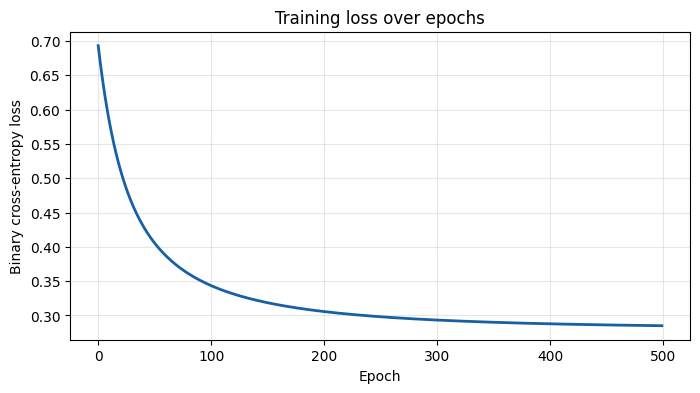

Train accuracy: 0.892
Test accuracy:  0.880
sklearn accuracy: 0.880


In [2]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


X, y = make_classification(
    n_samples=500, n_features=2,
    n_redundant=0, random_state=42
)


scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Training OUR model
model = LogisticRegressionScratch(lr=0.1, epochs=500)
model.fit(X_train, y_train)
model.plot_loss()

print(f"Train accuracy: {model.score(X_train, y_train):.3f}")
print(f"Test accuracy:  {model.score(X_test, y_test):.3f}")

# Verifying against sklearn
from sklearn.linear_model import LogisticRegression
sk_model = LogisticRegression()
sk_model.fit(X_train, y_train)
print(f"sklearn accuracy: {sk_model.score(X_test, y_test):.3f}")

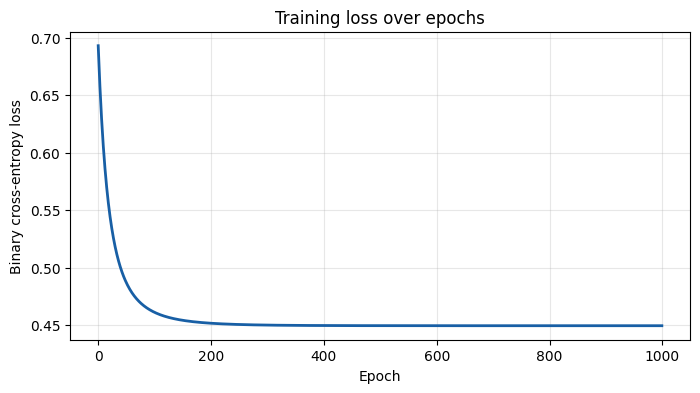


Train accuracy: 0.801
Test accuracy:  0.799

Feature weights (importance):
  Pclass      : w=-0.827  ↓ survival
  Sex         : w=+1.306  ↑ survival
  Age         : w=-0.412  ↓ survival
  Fare        : w=+0.146  ↑ survival
  Embarked    : w=+0.138  ↑ survival
  FamilySize  : w=-0.374  ↓ survival


In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


train = pd.read_csv(r'C:\Users\Hp\.vscode\Journey to the BEST\Week 1\train.csv')

# Quick feature engineering
train['Sex']        = train['Sex'].map({'male':0,'female':1})
train['Age']        = train['Age'].fillna(train['Age'].median())
train['Fare']       = train['Fare'].fillna(train['Fare'].median())
train['Embarked']   = train['Embarked'].fillna('S').map({'S':0,'C':1,'Q':2})
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1

FEATURES = ['Pclass','Sex','Age','Fare','Embarked','FamilySize']

X = train[FEATURES].values
y = train['Survived'].values


scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Train
lr_model = LogisticRegressionScratch(lr=0.1, epochs=1000)
lr_model.fit(X_train, y_train)
lr_model.plot_loss()

print(f"\nTrain accuracy: {lr_model.score(X_train, y_train):.3f}")
print(f"Test accuracy:  {lr_model.score(X_test,  y_test):.3f}")


print("\nFeature weights (importance):")
for feat, w in zip(FEATURES, lr_model.w):
    direction = "↑ survival" if w > 0 else "↓ survival"
    print(f"  {feat:12s}: w={w:+.3f}  {direction}")

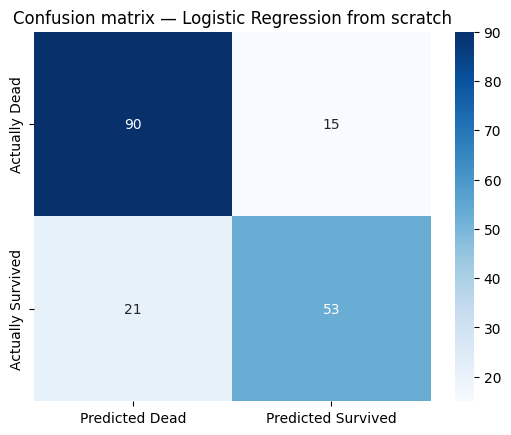

              precision    recall  f1-score   support

        Died       0.81      0.86      0.83       105
    Survived       0.78      0.72      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [4]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred = lr_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Dead','Predicted Survived'],
            yticklabels=['Actually Dead','Actually Survived'])
plt.title('Confusion matrix — Logistic Regression from scratch')
plt.show()

print(classification_report(y_test, y_pred,
      target_names=['Died','Survived']))

### MY WEIGHT ANALYSIS ###
Women and children first was real. Female=1 in your encoding,
so positive weight = higher survival.
The magnitude 1.306 is nearly double than every other feature.

Higher class number = lower class = lower survival.
1st class passengers had lifeboats near their cabins.
3rd class passengers were literally locked below deck in some accounts.

Older passengers with large families had more people to worry about,
making it harder to reach lifeboats quickly.

Fare and Pclass are correlated, so after Pclass is included,
Fare has little extra to say. This is called multicollinearity.